# Comprehensive Model Visualization

This notebook generates visualizations for all skin lesion classification models.

## Models Covered:
1. Custom CNN
2. KAN-ViT
3. EfficientNetB0-KANViT
4. EfficientNetB0-KANViT-MLP (Unfrozen Backbone)
5. EfficientNetB3-KANViT-MLP

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Base paths
WORKSPACE = Path(os.environ.get("SKIN_LESION_ROOT", "."))
DATA_DIR = WORKSPACE / "hair removal dataset" / "skin-ds-processed"

# Model configurations
MODELS = {
    "Custom CNN V1": {
        "dir": "custom cnn v1",
        "weights": "v1_custom_cnn_skin_lesion_100_epochs.pth",
        "logs": "cnn_v1_training_logs.csv",
        "image_size": 224,
    },
    "Custom CNN V2": {
        "dir": "custom cnn v2",
        "weights": "v2_custom_cnn_skin_lesion_100_epochs.pth",
        "logs": "cnn_v2_training_logs.csv",
        "image_size": 224,
    },
    "KAN-ViT": {
        "dir": "kanvit",
        "weights": "kan_vit_skin_lesion_30_epochs.pth",
        "logs": "kanvit_training_logs.csv",
        "image_size": 160,
    },
    "EfficientNetB0-KANViT": {
        "dir": "efficientnetb0_kanvit",
        "weights": "efficientnetb0_kan_vit_skin_lesion_35_epochs.pth",
        "logs": "efficientnetb0_kanvit_training_logs.csv",
        "image_size": 160,
    },
    "EfficientNetB0-KANViT-MLP": {
        "dir": "b0_kanvit_with_mlp_unfreezed backcone",
        "weights": "efficientnetb0_kan_vit_mlp_hybrid_skin_lesion_50_epochs.pth",
        "logs": "efficientnetb0_kan_vit_mlp_hybrid_skin_lesion_training_logs.csv",
        "image_size": 160,
    },
    "EfficientNetB3-KANViT-MLP": {
        "dir": "efficientnetb3_kanvit_mlp",
        "weights": "efficientnetb3_kan_vit_skin_lesion_50_epochs.pth",
        "logs": "efficientnetb3_training_logs.csv",
        "image_size": 160,
    },
}

CLASS_NAMES = [
    'Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions',
    'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles',
    'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions'
]
NUM_CLASSES = 14

print(f"Workspace: {WORKSPACE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Number of models: {len(MODELS)}")

Workspace: .
Data Directory: hair removal dataset/skin-ds-processed
Number of models: 6


## 2. Training History Visualization

In [2]:
def load_training_logs():
    """Load training logs from all models."""
    logs = {}
    for name, config in MODELS.items():
        if config["logs"] is None:
            continue
        log_path = WORKSPACE / config["dir"] / config["logs"]
        if log_path.exists():
            df = pd.read_csv(log_path)
            logs[name] = df
            print(f"✓ Loaded {name}: {len(df)} epochs")
        else:
            print(f"✗ Missing: {log_path}")
    return logs

training_logs = load_training_logs()

✓ Loaded Custom CNN V1: 100 epochs
✓ Loaded Custom CNN V2: 100 epochs
✓ Loaded KAN-ViT: 30 epochs
✓ Loaded EfficientNetB0-KANViT: 35 epochs
✓ Loaded EfficientNetB0-KANViT-MLP: 25 epochs
✓ Loaded EfficientNetB3-KANViT-MLP: 50 epochs


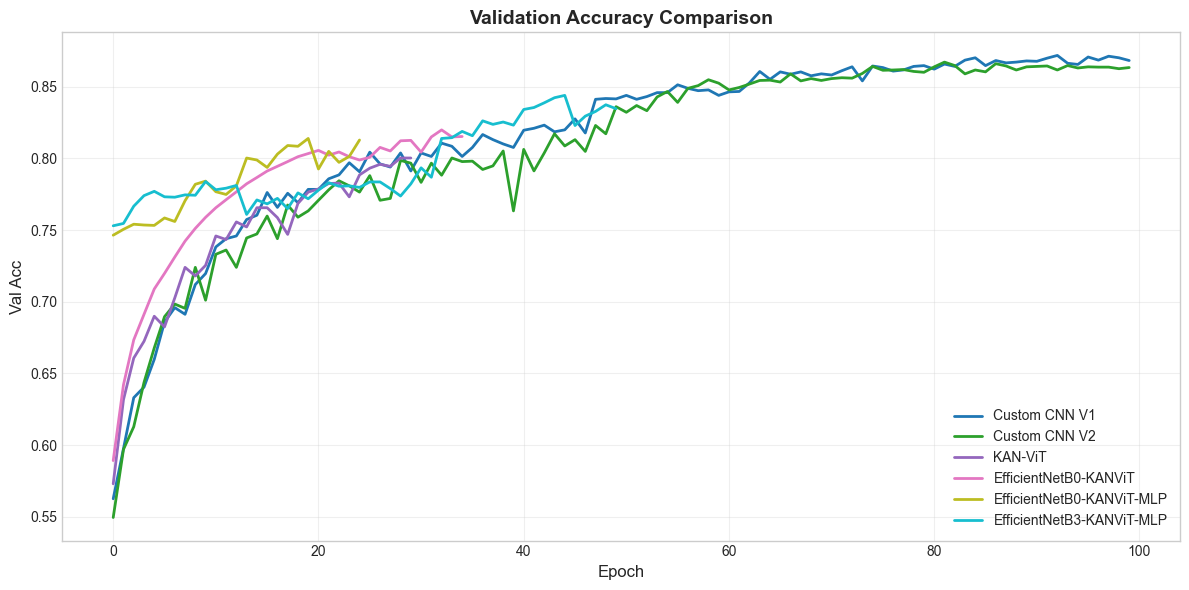

Saved: val_acc_comparison.png


In [3]:
def plot_training_curves(logs, metric='val_acc', title='Validation Accuracy'):
    """Plot training curves for all models."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(logs)))
    
    for (name, df), color in zip(logs.items(), colors):
        if metric in df.columns:
            ax.plot(df['epoch'], df[metric], label=name, linewidth=2, color=color)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(WORKSPACE / f'{metric}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {metric}_comparison.png")

# Plot validation accuracy
plot_training_curves(training_logs, 'val_acc', 'Validation Accuracy Comparison')

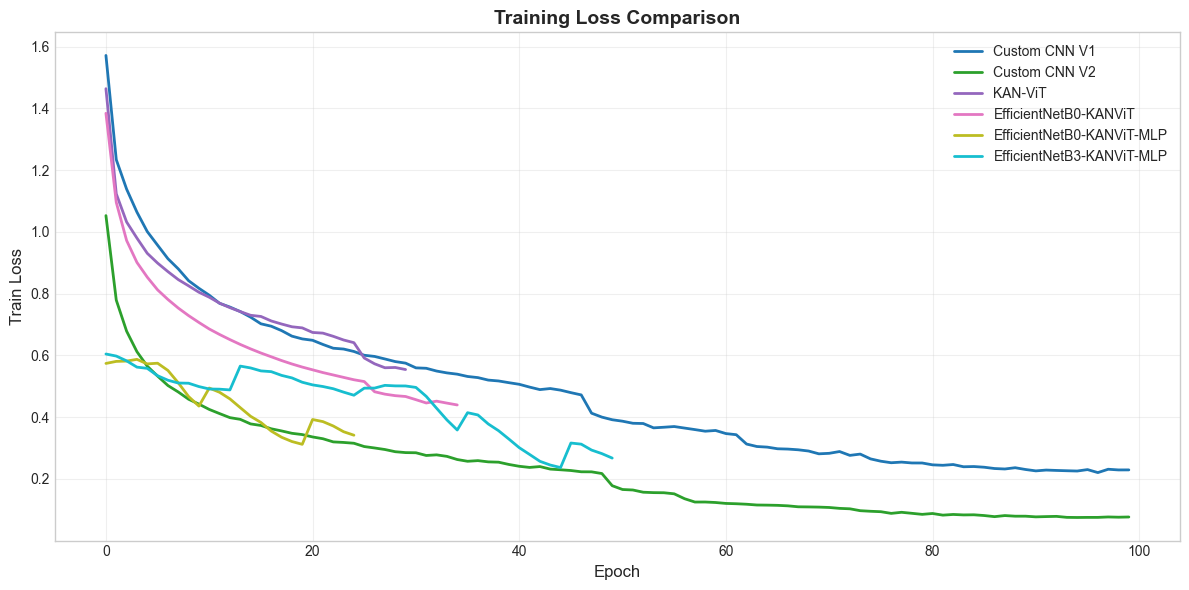

Saved: train_loss_comparison.png


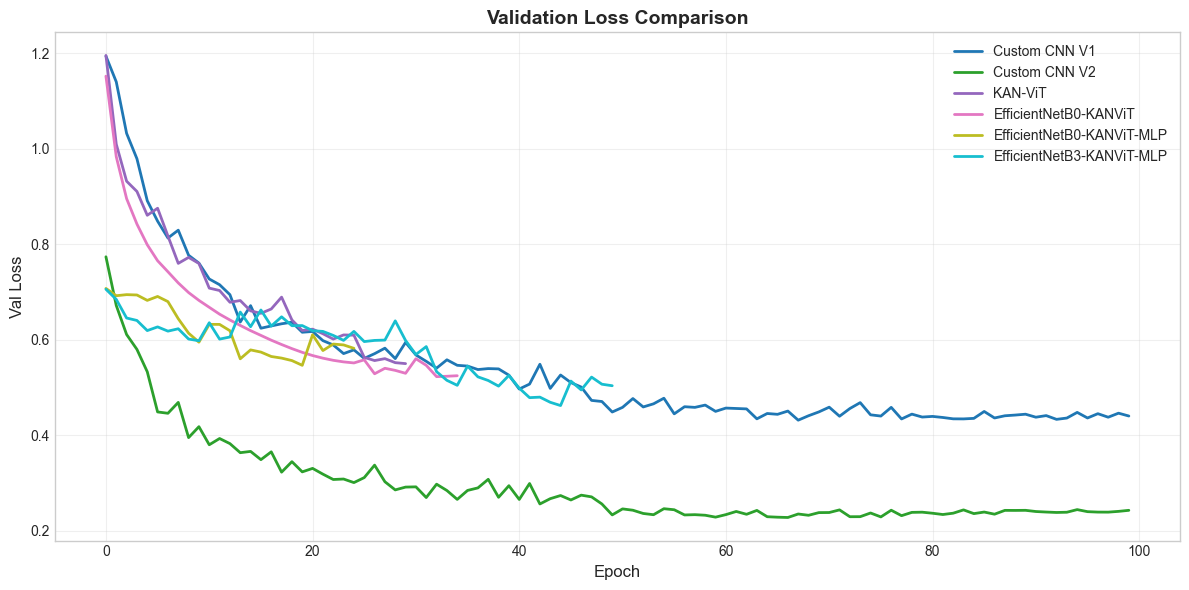

Saved: val_loss_comparison.png


In [4]:
# Plot training and validation loss
plot_training_curves(training_logs, 'train_loss', 'Training Loss Comparison')
plot_training_curves(training_logs, 'val_loss', 'Validation Loss Comparison')

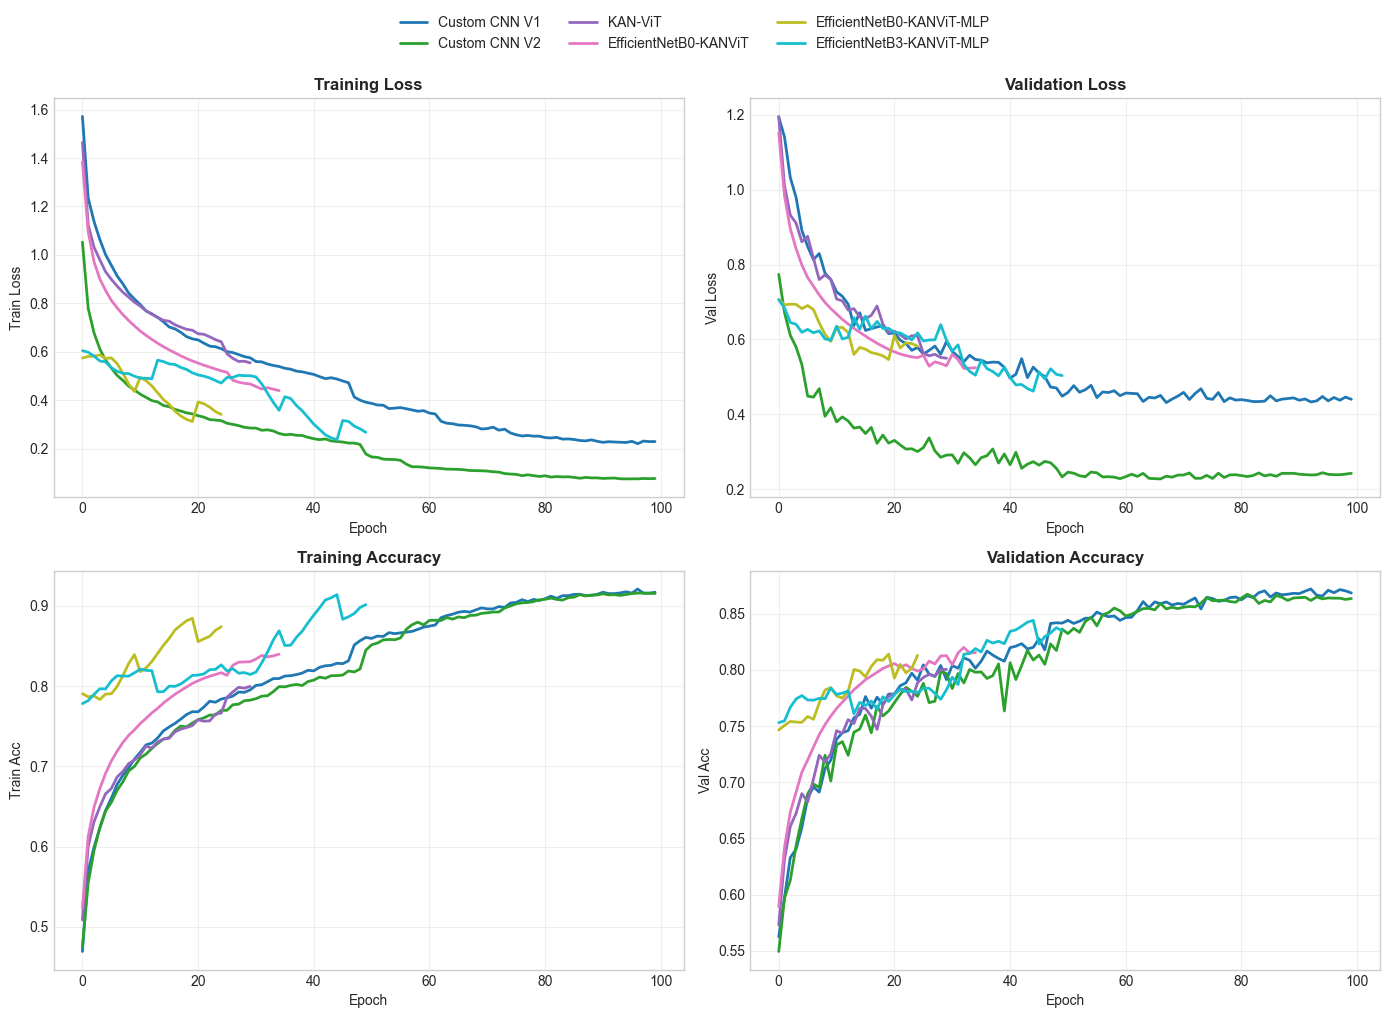

Saved: training_curves_combined.png


In [5]:
def plot_combined_curves(logs):
    """Plot combined loss and accuracy curves."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = [
        ('train_loss', 'Training Loss', axes[0, 0]),
        ('val_loss', 'Validation Loss', axes[0, 1]),
        ('train_acc', 'Training Accuracy', axes[1, 0]),
        ('val_acc', 'Validation Accuracy', axes[1, 1]),
    ]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(logs)))
    
    for metric, title, ax in metrics:
        for (name, df), color in zip(logs.items(), colors):
            if metric in df.columns:
                ax.plot(df['epoch'], df[metric], label=name, linewidth=2, color=color)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Single legend for all
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(WORKSPACE / 'training_curves_combined.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves_combined.png")

plot_combined_curves(training_logs)

In [6]:
def get_best_metrics(logs):
    """Extract best metrics from each model."""
    results = []
    for name, df in logs.items():
        best_epoch = df['val_acc'].idxmax() if 'val_acc' in df.columns else 0
        results.append({
            'Model': name,
            'Best Epoch': int(df.loc[best_epoch, 'epoch']) if 'epoch' in df.columns else best_epoch,
            'Best Val Acc': df['val_acc'].max() if 'val_acc' in df.columns else None,
            'Final Train Acc': df['train_acc'].iloc[-1] if 'train_acc' in df.columns else None,
            'Final Val Loss': df['val_loss'].iloc[-1] if 'val_loss' in df.columns else None,
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Best Val Acc', ascending=False)
    return results_df

best_metrics = get_best_metrics(training_logs)
print("\n=== Best Validation Accuracy Summary ===")
print(best_metrics.to_string(index=False))


=== Best Validation Accuracy Summary ===
                    Model  Best Epoch  Best Val Acc  Final Train Acc  Final Val Loss
            Custom CNN V1          92      0.871858         0.916957        0.439954
            Custom CNN V2          81      0.867200         0.915500        0.242300
EfficientNetB3-KANViT-MLP          44      0.843989         0.901576        0.503439
    EfficientNetB0-KANViT          32      0.819900         0.839800        0.524400
EfficientNetB0-KANViT-MLP          19      0.813934         0.873951        0.581833
                  KAN-ViT          28      0.800300         0.799700        0.549800


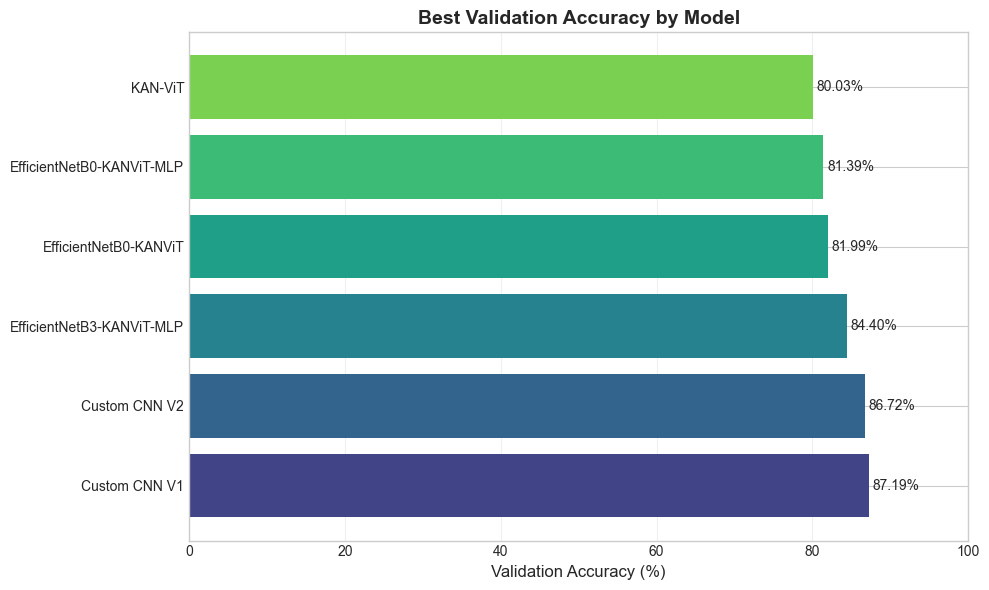

Saved: best_accuracy_comparison.png


In [7]:
def plot_best_accuracy_comparison(metrics_df):
    """Bar chart of best validation accuracy."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(metrics_df)))
    bars = ax.barh(metrics_df['Model'], metrics_df['Best Val Acc'] * 100, color=colors)
    
    # Add value labels
    for bar, val in zip(bars, metrics_df['Best Val Acc']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val*100:.2f}%', va='center', fontsize=10)
    
    ax.set_xlabel('Validation Accuracy (%)', fontsize=12)
    ax.set_title('Best Validation Accuracy by Model', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(WORKSPACE / 'best_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: best_accuracy_comparison.png")

plot_best_accuracy_comparison(best_metrics)

## 3. Cross-Model Comparison Summary

In [8]:
def create_model_comparison_table(logs):
    """Create comprehensive comparison table."""
    data = []
    for name, df in logs.items():
        if 'val_acc' not in df.columns:
            continue
        
        best_idx = df['val_acc'].idxmax()
        final_idx = len(df) - 1
        
        data.append({
            'Model': name,
            'Total Epochs': len(df),
            'Best Val Acc': f"{df['val_acc'].max()*100:.2f}%",
            'Best Epoch': int(df.loc[best_idx, 'epoch']) if 'epoch' in df.columns else best_idx,
            'Final Train Acc': f"{df['train_acc'].iloc[final_idx]*100:.2f}%" if 'train_acc' in df.columns else 'N/A',
            'Final Val Acc': f"{df['val_acc'].iloc[final_idx]*100:.2f}%",
            'Generalization Gap': f"{(df['train_acc'].iloc[final_idx] - df['val_acc'].iloc[final_idx])*100:.2f}%" if 'train_acc' in df.columns else 'N/A',
        })
    
    return pd.DataFrame(data)

comparison_table = create_model_comparison_table(training_logs)
print("\n" + "="*80)
print("CROSS-MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_table.to_string(index=False))
print("="*80)

# Save to CSV
comparison_table.to_csv(WORKSPACE / 'model_comparison_summary.csv', index=False)
print(f"\nSaved: model_comparison_summary.csv")


CROSS-MODEL COMPARISON SUMMARY
                    Model  Total Epochs Best Val Acc  Best Epoch Final Train Acc Final Val Acc Generalization Gap
            Custom CNN V1           100       87.19%          92          91.70%        86.83%              4.87%
            Custom CNN V2           100       86.72%          81          91.55%        86.34%              5.21%
                  KAN-ViT            30       80.03%          28          79.97%        80.03%             -0.06%
    EfficientNetB0-KANViT            35       81.99%          32          83.98%        81.53%              2.45%
EfficientNetB0-KANViT-MLP            25       81.39%          19          87.40%        81.28%              6.11%
EfficientNetB3-KANViT-MLP            50       84.40%          44          90.16%        83.47%              6.69%

Saved: model_comparison_summary.csv


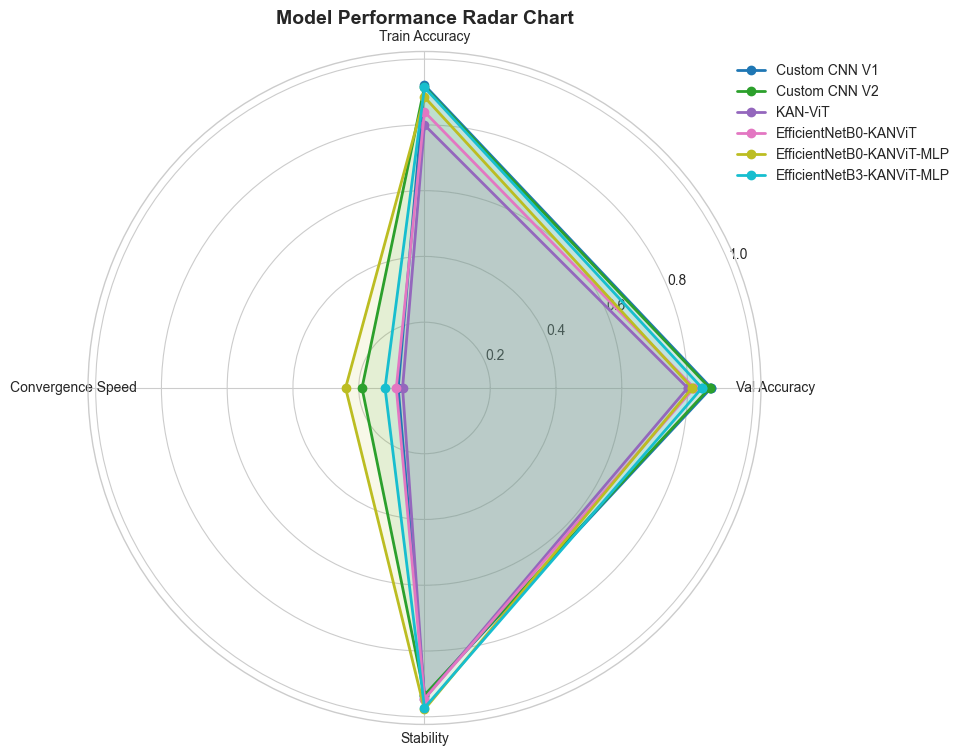

Saved: model_radar_comparison.png


In [9]:
def plot_radar_comparison(logs):
    """Create radar chart for model comparison."""
    from math import pi
    
    # Metrics to compare (normalized to 0-1)
    metrics = []
    for name, df in logs.items():
        if 'val_acc' not in df.columns:
            continue
        metrics.append({
            'Model': name,
            'Val Accuracy': df['val_acc'].max(),
            'Train Accuracy': df['train_acc'].max() if 'train_acc' in df.columns else 0,
            'Convergence Speed': 1 - (df['val_acc'].idxmax() / len(df)),  # Higher is better
            'Stability': 1 - df['val_acc'].std(),  # Higher is better
        })
    
    if not metrics:
        print("No metrics available for radar chart")
        return
    
    df_radar = pd.DataFrame(metrics)
    categories = ['Val Accuracy', 'Train Accuracy', 'Convergence Speed', 'Stability']
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]  # Complete the loop
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(df_radar)))
    
    for idx, row in df_radar.iterrows():
        values = [row[cat] for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
        ax.fill(angles, values, alpha=0.1, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title('Model Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.tight_layout()
    plt.savefig(WORKSPACE / 'model_radar_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: model_radar_comparison.png")

plot_radar_comparison(training_logs)